**Deep Learning**

Deep Learning is a subfield of Machine Learning that uses Artificial Neural Networks with multiple layers to learn patterns from data. It automatically extracts features and improves performance when more data is provided.

In [ ]:
# Import numpy for numerical operations
import numpy as np

# Import pandas for loading CSV dataset
import pandas as pd

# Import matplotlib for plotting graphs and images
import matplotlib.pyplot as plt

# Import Sequential model to build neural network layer by layer
from tensorflow.keras.models import Sequential

# Import Dense for fully connected layers
# Dropout for regularization
# BatchNormalization for stabilizing training
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Import Adam optimizer for gradient descent optimization
from tensorflow.keras.optimizers import Adam

# Import L2 regularizer to reduce overfitting
from tensorflow.keras.regularizers import l2

# Import function to convert labels into one-hot encoded format
from tensorflow.keras.utils import to_categorical

# Import evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report

# Import seaborn for heatmap visualization
import seaborn as sns


**Load Dataset**

In [ ]:
# Load training CSV file
train_data = pd.read_csv("fashion-mnist_train.csv")

# Load testing CSV file
test_data = pd.read_csv("fashion-mnist_test.csv")

# Print dataset shape
print("Training Data Shape:", train_data.shape)
print("Testing Data Shape:", test_data.shape)


Training Data Shape: (60000, 785)
Testing Data Shape: (10000, 785)


**Separate Features and Labels**

In [ ]:

# Separate pixel values (features) from training data
X_train = train_data.iloc[:,1:].values

# Separate labels from training data
y_train = train_data.iloc[:,0].values

# Separate pixel values (features) from testing data
X_test = test_data.iloc[:,1:].values

# Separate labels from testing data
y_test = test_data.iloc[:,0].values


**Normalize Pixel Values**

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0
# Normalize pixel values between 0 and 1
# This improves training speed and model performance

**One Hot Encoding (For Multi-class Classification)**

In [ ]:
# Convert training labels into categorical format
y_train = to_categorical(y_train, 10)

# Convert testing labels into categorical format
y_test = to_categorical(y_test, 10)


**Visualize Sample Image**

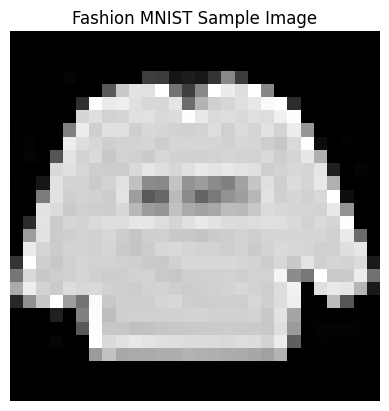

In [ ]:
# Display first image from training dataset
plt.imshow(X_train[0].reshape(28,28), cmap='gray')

# Add title
plt.title("Fashion MNIST Sample Image")

# Remove axis for clean visualization
plt.axis('off')

# Show image
plt.show()



**Build ANN Model Architecture**

In [ ]:
# Create Sequential model
model = Sequential()

# First hidden layer with 256 neurons
# ReLU activation adds non-linearity
# L2 regularization prevents overfitting
model.add(Dense(256, activation='relu', input_shape=(784,), kernel_regularizer=l2(0.001)))

# Normalize activations to stabilize learning
model.add(BatchNormalization())

# Dropout randomly disables neurons to reduce overfitting
model.add(Dropout(0.3))


# Second hidden layer with 128 neurons
model.add(Dense(128, activation='relu'))

# Batch normalization
model.add(BatchNormalization())

# Dropout layer
model.add(Dropout(0.3))


# Output layer with 10 neurons (10 classes)
# Softmax gives probability distribution
model.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compile Model**

In [ ]:
# Compile model using Adam optimizer and categorical crossentropy loss
model.compile(
    optimizer=Adam(learning_rate=0.001),   # Gradient descent optimizer
    loss='categorical_crossentropy',       # Loss function for multi-class classification
    metrics=['accuracy']                   # Performance metric
)


**Display Model Summary**

In [ ]:
model.summary()
# Print neural network architecture details

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,682 (924.54 KB)

 Trainable params: 235,914 (921.54 KB)

 Non-trainable params: 768 (3.00 KB)

**Train Model (Forward + Backpropagation)**

In [ ]:
# Train neural network
history = model.fit(
    X_train,              # Training images
    y_train,              # Training labels
    epochs=20,            # Number of training cycles
    batch_size=128,       # Number of samples per batch
    validation_data=(X_test, y_test)  # Validation dataset
)



Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7458 - loss: 1.0706 - val_accuracy: 0.8227 - val_loss: 0.7192
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8354 - loss: 0.6623 - val_accuracy: 0.8457 - val_loss: 0.5837
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8444 - loss: 0.5690 - val_accuracy: 0.8518 - val_loss: 0.5307
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8477 - loss: 0.5240 - val_accuracy: 0.8270 - val_loss: 0.5757
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8466 - loss: 0.5053 - val_accuracy: 0.8361 - val_loss: 0.5232
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8464 - loss: 0.4938 - val_accuracy: 0.8488 - val_loss: 0.4762
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8537 - loss: 0.4736 - val_accuracy: 0.7922 - val_loss: 0.6279
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8507 - loss: 0.4719 - val_accu

**Evaluate Model Performance**

In [ ]:
# Evaluate trained model on test dataset
test_loss, test_accuracy = model.evaluate(X_test, y_test)

# Print test accuracy
print("Test Accuracy:", test_accuracy)

# Print test loss
print("Test Loss:", test_loss)



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8532 - loss: 0.4528
Test Accuracy: 0.8554999828338623
Test Loss: 0.4519270360469818


**Prediction for Confusion Matrix**

In [ ]:
# Predict class probabilities for test dataset
y_pred = model.predict(X_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot encoded true labels to class labels
y_true = np.argmax(y_test, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Print confusion matrix values
print(cm)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[642   2  21  89   1   0 226   0  19   0]
 [  1 980   4   6   3   1   5   0   0   0]
 [  2   0 841  10  66   0  70   0  11   0]
 [  7  26  21 884  48   0  13   0   1   0]
 [  1   0 134  19 756   0  88   0   2   0]
 [  1   1   0   2   0 870   1  75   4  46]
 [ 57   3 112  42  48   0 713   0  25   0]
 [  0   0   0   0   0   6   0 946   0  48]
 [  2   0   9   3   3   0   6   3 973   1]
 [  0   0   0   0   0   3   0  46   1 950]]


In [ ]:
print(confusion_matrix(y_true, y_pred_classes))
print(classification_report(y_true, y_pred_classes))


[[642   2  21  89   1   0 226   0  19   0]
 [  1 980   4   6   3   1   5   0   0   0]
 [  2   0 841  10  66   0  70   0  11   0]
 [  7  26  21 884  48   0  13   0   1   0]
 [  1   0 134  19 756   0  88   0   2   0]
 [  1   1   0   2   0 870   1  75   4  46]
 [ 57   3 112  42  48   0 713   0  25   0]
 [  0   0   0   0   0   6   0 946   0  48]
 [  2   0   9   3   3   0   6   3 973   1]
 [  0   0   0   0   0   3   0  46   1 950]]
              precision    recall  f1-score   support

           0       0.90      0.64      0.75      1000
           1       0.97      0.98      0.97      1000
           2       0.74      0.84      0.79      1000
           3       0.84      0.88      0.86      1000
           4       0.82      0.76      0.79      1000
           5       0.99      0.87      0.93      1000
           6       0.64      0.71      0.67      1000
           7       0.88      0.95      0.91      1000
           8       0.94      0.97      0.96      1000
           9       0.91     

**Plot Heatmap (Evaluation Visualization)**

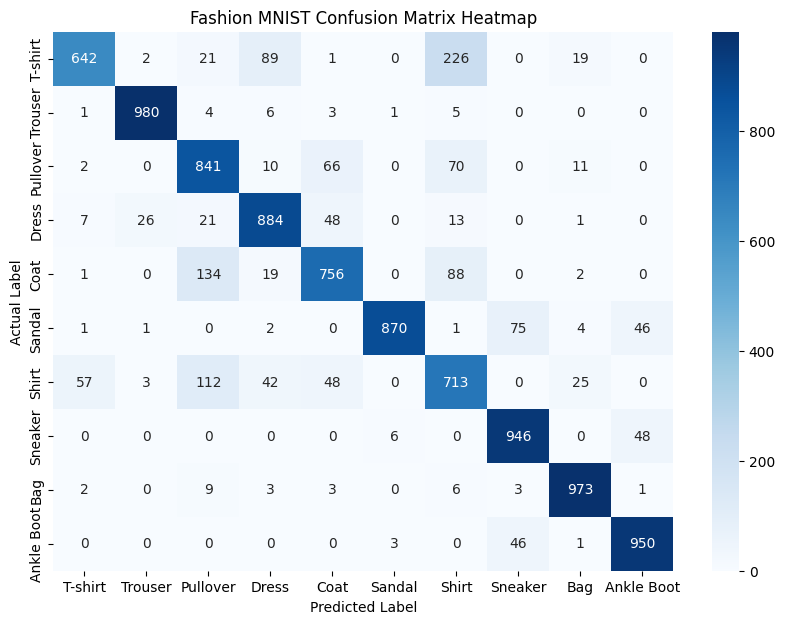

In [ ]:
# Define class labels
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle Boot']

# Set figure size
plt.figure(figsize=(10,7))

# Plot heatmap using seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

# Label x-axis
plt.xlabel("Predicted Label")

# Label y-axis
plt.ylabel("Actual Label")

# Add title
plt.title("Fashion MNIST Confusion Matrix Heatmap")

# Display heatmap
plt.show()


**Plot Accuracy Graph**

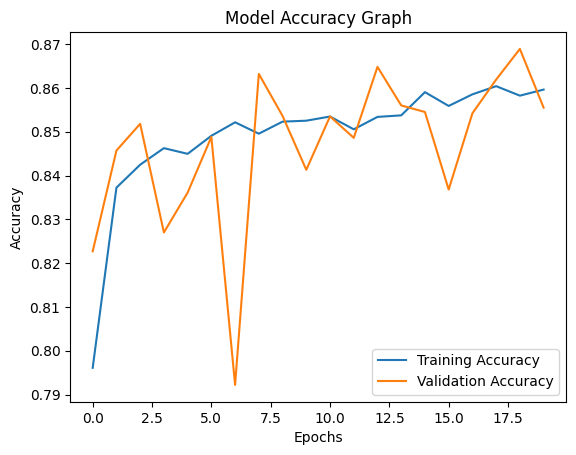

In [ ]:
# Plot training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')

# Plot validation accuracy
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Label x-axis
plt.xlabel("Epochs")

# Label y-axis
plt.ylabel("Accuracy")

# Add title
plt.title("Model Accuracy Graph")

# Add legend
plt.legend()

# Display graph
plt.show()



**Plot Loss Graph**

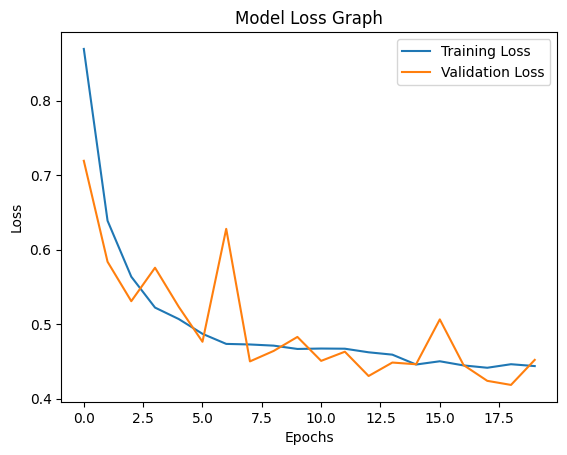

In [ ]:
# Plot training loss
plt.plot(history.history['loss'], label='Training Loss')

# Plot validation loss
plt.plot(history.history['val_loss'], label='Validation Loss')

# Label x-axis
plt.xlabel("Epochs")

# Label y-axis
plt.ylabel("Loss")

# Add title
plt.title("Model Loss Graph")

# Add legend
plt.legend()

# Display graph
plt.show()



**Save Trained Model**

In [ ]:
# Save trained deep learning model
model.save("fashion_mnist_dl_model.h5")

print("Model Saved Successfully")


Model Saved Successfully


**INFERENCE**

LOAD TEST DATA AGAIN

In [ ]:
# Load test dataset CSV file
test_data = pd.read_csv("fashion-mnist_test.csv")

# Separate input features (pixel values)
X_test = test_data.iloc[:,1:].values

# Separate actual labels
y_test = test_data.iloc[:,0].values

# Normalize pixel values
X_test = X_test / 255.0

In [ ]:
# CLASS LABEL NAMES
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]


In [ ]:
# Select one test image index
sample_index = 10   # You can change this number

# Get selected image
sample_image = X_test[sample_index]

# Reshape image for model input (1 sample with 784 features)
sample_image_reshaped = sample_image.reshape(1, 784)

# Perform forward propagation to get prediction
prediction = model.predict(sample_image_reshaped)

# Get class index with highest probability
predicted_class = np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [ ]:
sample_index = 5   # You can change index

sample_image = X_test[sample_index]

sample_image_reshaped = sample_image.reshape(1, 784)

prediction = model.predict(sample_image_reshaped)

predicted_class = np.argmax(prediction)

print("Predicted Class:", class_names[predicted_class])
print("Actual Class:", class_names[y_test[sample_index]])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Predicted Class: Shirt
Actual Class: Pullover


In [ ]:
print("Predicted Class :", class_names[predicted_class])
print("Actual Class    :", class_names[y_test[sample_index]])

Predicted Class : Dress
Actual Class    : Dress


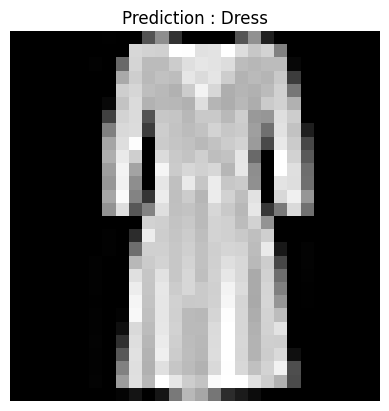

In [ ]:
# Display the test image
plt.imshow(sample_image.reshape(28,28), cmap='gray')

# Show predicted class on image
plt.title("Prediction : " + class_names[predicted_class])

# Remove axis
plt.axis('off')

# Display image
plt.show()

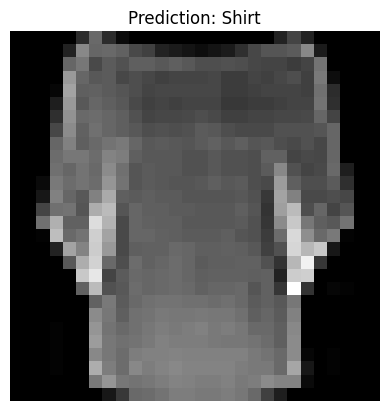

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(sample_image.reshape(28,28), cmap='gray')
plt.title("Prediction: " + class_names[predicted_class])
plt.axis('off')
plt.show()


In [ ]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print(predicted_labels[:10])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[6 1 2 6 4 6 8 2 5 0]
